In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
from scipy.spatial import ConvexHull, Delaunay
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import squidpy as sq
import sys
import tifffile as tf
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
from border_effects_kNN_del import sample_points_on_square, trunc_graphs, get_mibitof, get_squidpy_visium_datasets, delaunay_edges
from truncated_graphs import distance_to_border, compute_centrality_measures
from fit import fit_piece_wise_linear, fit_log, fit_constant, fit_exponential_saturation, fit_piece_wise_linear_old
from evaluate_fit import calculate_fit_qualities, log_likelihood

In [4]:
np.random.seed(41)

In [5]:
with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [6]:
with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [7]:
graph_type = "rnn_r=3"
assert graph_type in ["delaunay", "knn_k=5", "knn_k=10", "knn_k=15", "rnn_r=1", "rnn_r=2", "rnn_r=3"] 

In [8]:
try:
    node_dfs = pd.read_csv(f"../results/{graph_type}_centralities.csv") 
    node_dfs = node_dfs[node_dfs["dataset"] != "glioma_mibitof:CHOP_907_R1C6_whole_cell.tiff"]
except:
    if 1: 
        print(f"{graph_type} results not found")
    else:
        dfs = []
        with ProcessPoolExecutor() as executor:
            if graph_type == "delaunay":
                futures = [executor.submit(process_dataset_del, dataset) for dataset in datasets]
            elif graph_type == "knn":
                futures = [executor.submit(process_dataset_knn, dataset) for dataset in datasets]
            elif graph_type == "rnn":
                futures = [executor.submit(process_dataset_rnn, dataset) for dataset in datasets]

            for future in tqdm(as_completed(futures), total=len(futures)):
                dfs.append(future.result())
        
        node_dfs = pd.concat(dfs)
        node_dfs.to_csv(f"../results/{graph_type}_centralities.csv")   

In [9]:
measures = ["degree", "closeness", "betweenness", "harmonic", "clustering", "pagerank"]

def get_fits(dataset, dataset_df):
    d = dataset_df["distance_to_border"].values
    result_dfs = list()
    result = dict()
    for measure in measures:
        result[measure] = list()
        C_true = dataset_df[measure].values
        
        a, C_const = fit_constant(C_true)        
        ll = log_likelihood(C_true, C_const)
        result[measure] += [a, ll]
        
        m, c0, b, C_pieli = fit_piece_wise_linear(d, C_true)
        ll = log_likelihood(C_true, C_pieli)
        result[measure] += [m, c0, b, ll]
        
        a, b, C_log = fit_log(d, C_true)
        ll = log_likelihood(C_true, C_log)
        result[measure] += [a, b, ll]
        
        a, b, c, C_exp = fit_exponential_saturation(d, C_true)
        ll = log_likelihood(C_true, C_exp)
        result[measure] += [a, b, c, ll]
        result_dfs.append(pd.DataFrame(result[measure], columns=[measure], index=["const_a", "const_ll", "pieli_m", "pieli_c", "pieli_b", "pieli_ll", "log_a", "log_b", "log_ll", "exp_a", "exp_b", "exp_c", "exp_ll"]).T)
    result = pd.concat(result_dfs)
    result["dataset"] = dataset
    result["num_nodes"] = len(C_true)
    return result

In [10]:
dfs = list()
with ProcessPoolExecutor() as executor:
    futures = [executor.submit(get_fits, dataset, dataset_df) for dataset, dataset_df in node_dfs.groupby("dataset")]

    for future in tqdm(as_completed(futures), total=len(futures)):
        dfs.append(future.result())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1041/1041 [02:43<00:00,  6.36it/s]


In [11]:
conc = pd.concat(dfs)

In [12]:
heatmap_matrix, conc = calculate_fit_qualities(conc)

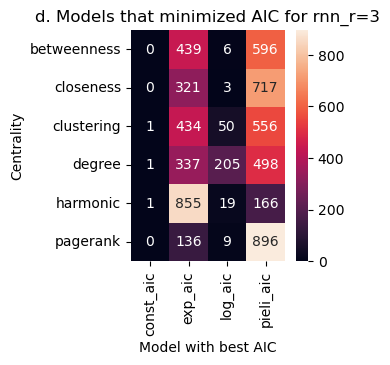

In [13]:
plt.figure(figsize=(3,3))
sns.heatmap(heatmap_matrix, annot=True, square=True, fmt=".0f")
plt.ylabel("Centrality")
plt.xlabel("Model with best AIC")
plt.title(f"d. Models that minimized AIC for {graph_type}")
plt.savefig(f"../result_plots/fits/{graph_type}_AIC_fits.pdf", bbox_inches="tight")

In [14]:
pal = {"const": (0.5, 0.5, 0.5), "exp": (0.74, 0, 0.2), "log": (1, 0.6, 0), "pieli": (0.31, 0.02, 1)}

In [15]:
markers = {1: "v", -1: "^", 0: "o"}  # if fit monotonocially decreases, then error is positive at borders

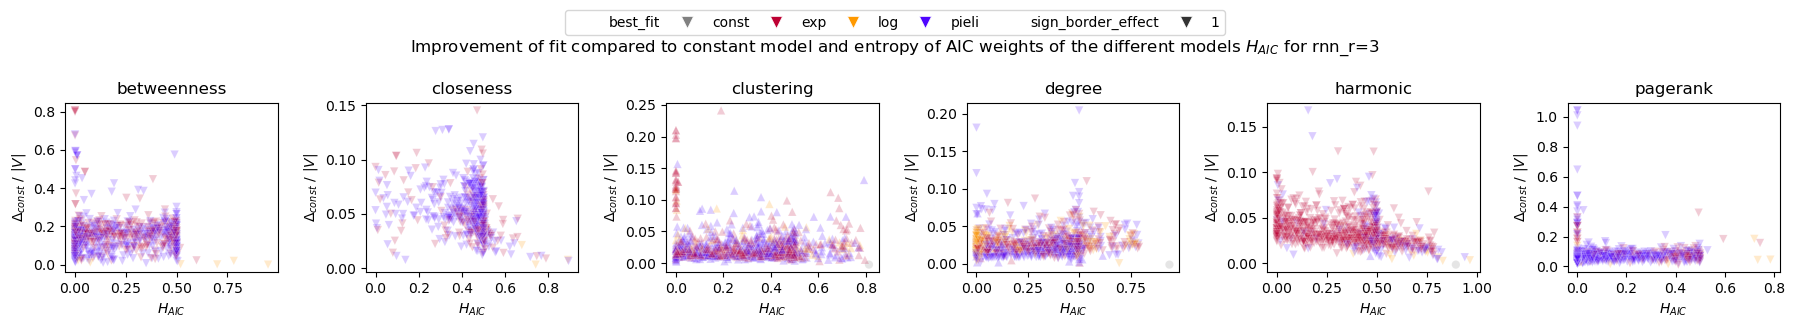

In [17]:
f, axs = plt.subplots(1, 6, figsize=(18, 3))
for i, (measure, df) in enumerate(conc.groupby("measure")):
    legend = "full" if (i == 5) else False
    sns.scatterplot(df, x="akaike_weights_entropy", y="d_aic_per_node", ax=axs[i], hue="best_fit", palette=pal, markers=markers, style="sign_border_effect", legend=legend, hue_order=list(pal.keys()), alpha=0.2)
    axs[i].set_title(measure)
    axs[i].set_ylabel("$Δ_{const}~/~|V|$")
    axs[i].set_xlabel("$H_{AIC}$")

plt.suptitle(f"Improvement of fit compared to constant model and entropy of AIC weights of the different models $H_{{AIC}}$ for {graph_type}")

handles, labels = axs[-1].get_legend_handles_labels()
leg = f.legend(handles, labels, loc='upper center',
               ncol=len(handles),
               bbox_to_anchor=(0.5, 1.1),
               columnspacing=0.9)

for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_markersize(8)
    
axs[-1].legend_.remove()

plt.tight_layout()
plt.savefig(f"../result_plots/fits/{graph_type}_delta_aic_over_aic_entropy.pdf", bbox_inches="tight")